In [1]:
import numpy as np
import pandas as pd

In [4]:
import pandas as pd

data = pd.read_excel(r'C:\Users\Aryan\OneDrive\Desktop\Copy of med-insurance.xlsx')

print(data.shape)

(1338, 7)


In [5]:
data.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


# Use Label Encoder to encode Categorical Columns

In [6]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
data['sex']=le.fit_transform(data['sex'])
data['smoker']=le.fit_transform(data['smoker'])
data['region']=le.fit_transform(data['region'])

# lets check the head again
data.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,1,3,16884.92
1,18,1,33.8,1,0,2,1725.55
2,28,1,33.0,3,0,2,4449.46
3,33,1,22.7,0,0,1,21984.47
4,32,1,28.9,0,0,1,3866.86


# Check  the Distribution of Expenses Column

C:\Users\Aryan\AppData\Local\Temp\ipykernel_800\552436794.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['expenses'])


<Axes: xlabel='expenses', ylabel='Density'>

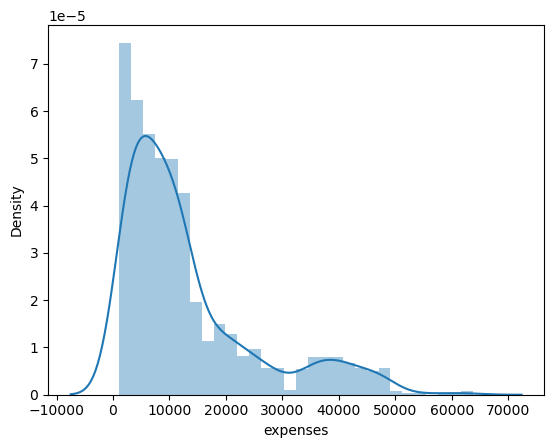

In [7]:
import seaborn as sns
sns.distplot(data['expenses'])

# Apply Log Transformation into the Expenses Column

C:\Users\Aryan\AppData\Local\Temp\ipykernel_800\3948421207.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['expenses'])


<Axes: xlabel='expenses', ylabel='Density'>

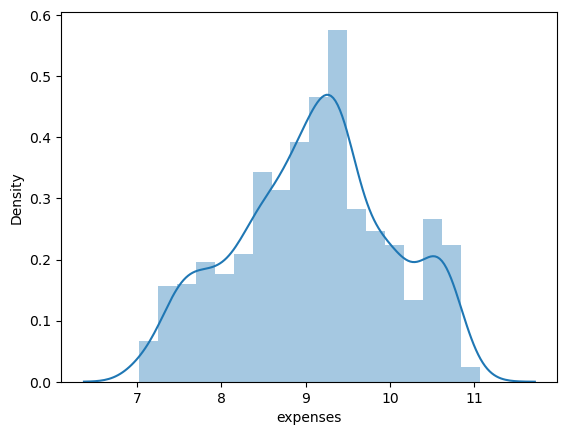

In [8]:
data['expenses']=np.log1p(data['expenses'])

# lets again check the distribution
sns.distplot(data['expenses'])


## Hurray, now we can see that the Expenses Column is in Normal Distribution, hence we can apply the Linear Regression Algorithms into this Dataset

# Apply Splitting

In [10]:
y=data['expenses']
x=data.drop(['expenses'],axis=1)

print(x.shape)
print(y.shape)

(1338, 6)
(1338,)


In [11]:
# lets perform train test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 6)
(268, 6)
(1070,)
(268,)


### Apply Standard Scaling

In [12]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

### Apply Linear Regression Model

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

### Evaluate the Model Performance

In [14]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

0.7890687945605839
